# DTL Comparison Tables

This notebook loads DTL log files with `pandas` and automatically builds comparison tables for the selected networks, settings, policy models, and graph-model variants.

Each detailed table contains three rows:
- `cityflow` at epoch 0 from `Sim Rollout`
- `sumo` at epoch 0 from `Real rollout`
- `sumo` at the minimum real-rollout average travel time

Two summary tables are generated:
- Direct transfer summary from `sumo epoch 0`
- Transition-model summary from `sumo min ATT` for `gat` and `ugat`

In [1]:
from pathlib import Path
from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT_DIR = Path("raw_results/sim2real_transitions/cityflow_presslight")

SELECTED_NETWORKS = [
    "bullhead_1",
    "cologne1",
    "hz1x1",
    "ingolstadt1",
    "tempe_1x1",
]

SELECTED_SETTINGS = [1, 2, 3, 4]

SELECTED_MODELS = ["presslight"]

SELECTED_GAT_MODELS = ["gat", "ugat"]

SUMMARY_TRANSITION_MODELS = ["gat", "ugat"]

COLUMNS = [
    "exp_name",
    "mode",
    "epoch",
    "travel_time",
    "ignore",
    "reward",
    "queue",
    "delay",
    "throughput",
]


In [2]:
def summarize_log(log_path: Path) -> dict:
    df = pd.read_csv(log_path, sep="\t", header=None, names=COLUMNS)
    exp_name = df.iloc[0]["exp_name"]

    network, remainder = exp_name.split("_setting", 1)
    setting_str, remainder = remainder.split("_", 1)
    tsc_model, transition_model = remainder.rsplit("_", 1)
    setting = int(setting_str)

    sim_epoch0_row = df[(df["mode"] == "Sim Rollout") & (df["epoch"] == 0)].iloc[0]
    real_epoch0_row = df[(df["mode"] == "Real rollout") & (df["epoch"] == 0)].iloc[0]
    real_rollout = df[df["mode"] == "Real rollout"]
    lowest_real_row = real_rollout.loc[real_rollout["travel_time"].idxmin()]

    comparison_table = pd.DataFrame([
        {
            "network": network,
            "setting": f"Setting {setting}",
            "tsc_model": tsc_model,
            "transition_model": transition_model,
            "result": "cityflow epoch 0",
            "travel_time": sim_epoch0_row["travel_time"],
            "reward": sim_epoch0_row["reward"],
            "queue": sim_epoch0_row["queue"],
            "delay": sim_epoch0_row["delay"],
            "throughput": sim_epoch0_row["throughput"],
        },
        {
            "network": network,
            "setting": f"Setting {setting}",
            "tsc_model": tsc_model,
            "transition_model": transition_model,
            "result": "sumo epoch 0",
            "travel_time": real_epoch0_row["travel_time"],
            "reward": real_epoch0_row["reward"],
            "queue": real_epoch0_row["queue"],
            "delay": real_epoch0_row["delay"],
            "throughput": real_epoch0_row["throughput"],
        },
        {
            "network": network,
            "setting": f"Setting {setting}",
            "tsc_model": tsc_model,
            "transition_model": transition_model,
            "result": "sumo min ATT",
            "travel_time": lowest_real_row["travel_time"],
            "reward": lowest_real_row["reward"],
            "queue": lowest_real_row["queue"],
            "delay": lowest_real_row["delay"],
            "throughput": lowest_real_row["throughput"],
        },
    ])

    return {
        "log_path": log_path,
        "exp_name": exp_name,
        "network": network,
        "setting": setting,
        "tsc_model": tsc_model,
        "transition_model": transition_model,
        "table": comparison_table,
    }


def discover_logs(root_dir: Path, networks: list[str], settings: list[int], models: list[str], gat_models: list[str]) -> list[dict]:
    discovered = []

    for network in networks:
        logger_dir = root_dir / network / "test" / "logger"
        for log_path in sorted(logger_dir.glob("*_DTL.log")):
            info = summarize_log(log_path)
            if info["network"] not in networks:
                continue
            if info["setting"] not in settings:
                continue
            if info["tsc_model"] not in models:
                continue
            if info["transition_model"] not in gat_models:
                continue
            discovered.append(info)

    discovered.sort(key=lambda item: (item["network"], item["setting"], item["tsc_model"], item["transition_model"]))
    return discovered


results = discover_logs(
    root_dir=ROOT_DIR,
    networks=SELECTED_NETWORKS,
    settings=SELECTED_SETTINGS,
    models=SELECTED_MODELS,
    gat_models=SELECTED_GAT_MODELS,
)

print(f"Discovered {len(results)} matching DTL logs.")


Discovered 40 matching DTL logs.


In [3]:
dt_rows = []
summary_rows = []

for result in results:
    table = result["table"]
    setting_label = f"Setting {result['setting']}"
    network = result["network"]

    cityflow_epoch0 = table.loc[table["result"] == "cityflow epoch 0", "travel_time"].iloc[0]
    sumo_epoch0 = table.loc[table["result"] == "sumo epoch 0", "travel_time"].iloc[0]
    sumo_min_att = table.loc[table["result"] == "sumo min ATT", "travel_time"].iloc[0]

    dt_rows.append({
        "setting": setting_label,
        "network": network,
        "travel_time": sumo_epoch0,
        "cityflow_epoch0": cityflow_epoch0,
    })

    summary_rows.append({
        "setting": setting_label,
        "network": network,
        "transition_model": result["transition_model"],
        "travel_time": sumo_min_att,
        "cityflow_epoch0": cityflow_epoch0,
    })

dt_df = pd.DataFrame(dt_rows).drop_duplicates(subset=["setting", "network"])
dt_table = dt_df.pivot(index="setting", columns="network", values="travel_time")
dt_table = dt_table.reindex(index=[f"Setting {s}" for s in SELECTED_SETTINGS])
dt_table = dt_table.reindex(columns=SELECTED_NETWORKS)

summary_df = pd.DataFrame(summary_rows).drop_duplicates(subset=["setting", "network", "transition_model"])
summary_table = summary_df.pivot(
    index="setting",
    columns=["network", "transition_model"],
    values="travel_time",
)
summary_columns = pd.MultiIndex.from_product([SELECTED_NETWORKS, SUMMARY_TRANSITION_MODELS])
summary_table = summary_table.reindex(index=[f"Setting {s}" for s in SELECTED_SETTINGS])
summary_table = summary_table.reindex(columns=summary_columns)

display(Markdown("## Direct Transfer Table"))
display(dt_table.style.format("{:.2f}"))
display(Markdown("## Transition Summary Table"))
display(summary_table.style.format("{:.2f}"))


## Direct Transfer Table

network,bullhead_1,cologne1,hz1x1,ingolstadt1,tempe_1x1
setting,,,,,
Setting 1,139.50,131.40,175.20,103.60,180.60
Setting 2,139.10,149.30,176.50,102.00,183.30
Setting 3,143.10,126.00,191.10,93.70,188.40
Setting 4,152.30,209.70,244.40,113.90,555.30


## Transition Summary Table

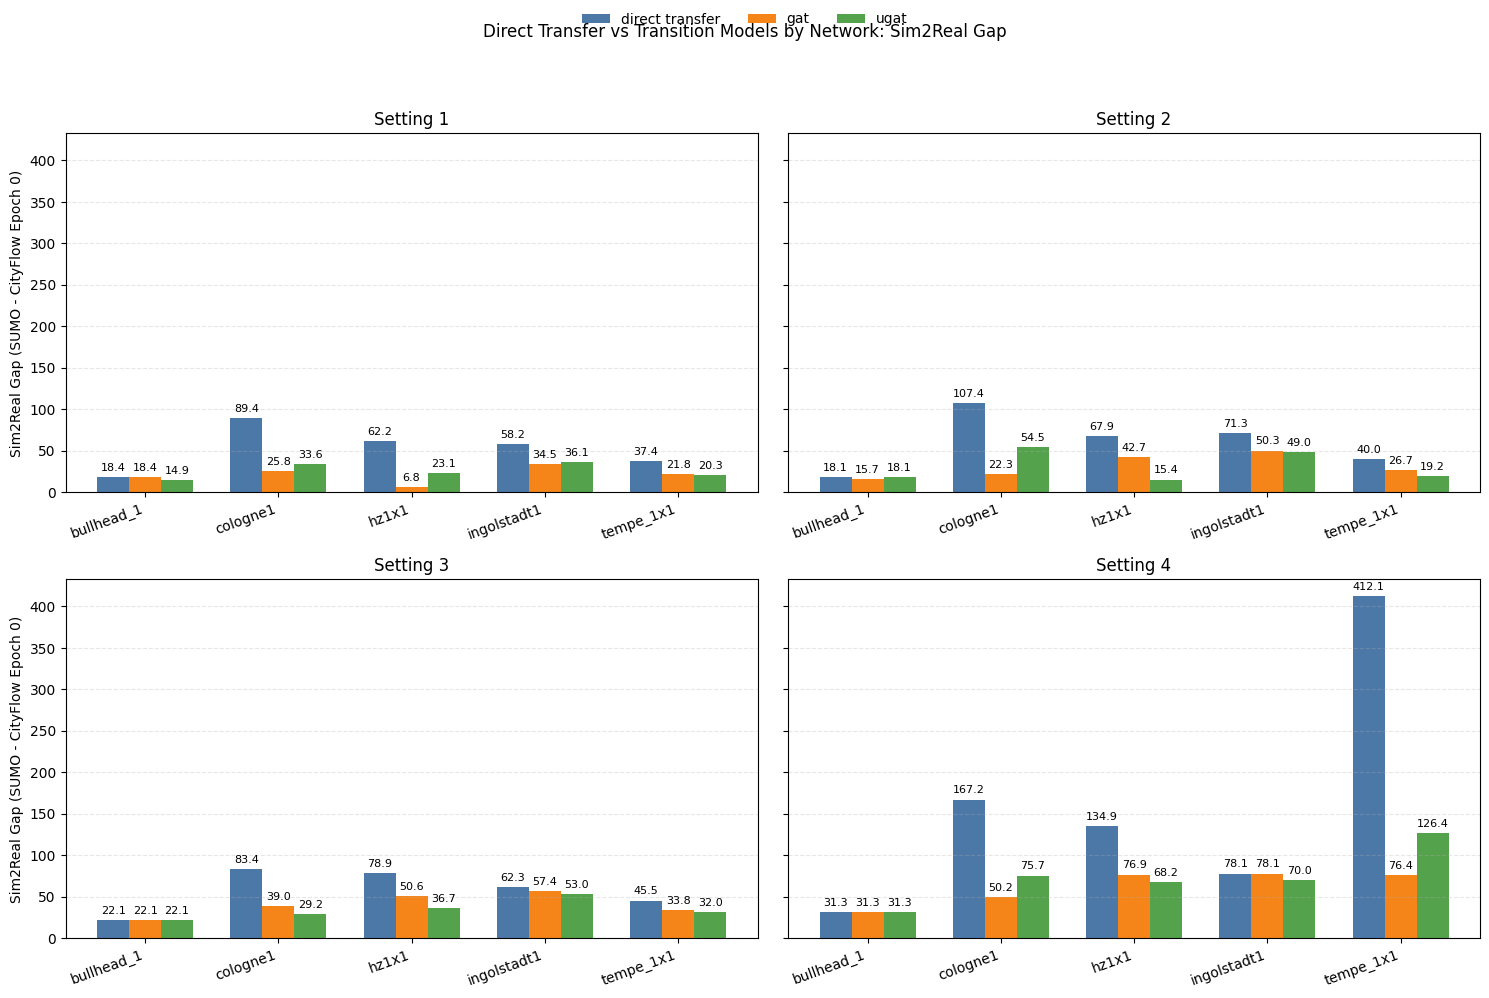

In [4]:
BAR_ORDER = ["direct transfer", "gat", "ugat"]
BAR_COLORS = {
    "direct transfer": "#4C78A8",
    "gat": "#F58518",
    "ugat": "#54A24B",
}

chart_df = pd.concat(
    [
        dt_df.assign(series="direct transfer"),
        summary_df.rename(columns={"transition_model": "series"}),
    ],
    ignore_index=True,
)
chart_df = chart_df.drop_duplicates(subset=["setting", "network", "series"])
chart_df["sim2real_gap"] = chart_df["travel_time"] - chart_df["cityflow_epoch0"]

settings = [f"Setting {s}" for s in SELECTED_SETTINGS]
x = np.arange(len(SELECTED_NETWORKS))
width = 0.24

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.flatten()

for ax, setting in zip(axes, settings):
    subset = chart_df[chart_df["setting"] == setting]
    pivoted = (
        subset.pivot(index="network", columns="series", values="sim2real_gap")
        .reindex(index=SELECTED_NETWORKS, columns=BAR_ORDER)
    )

    for offset, series in zip((-width, 0, width), BAR_ORDER):
        values = pivoted[series].to_numpy(dtype=float)
        bars = ax.bar(
            x + offset,
            values,
            width=width,
            label=series,
            color=BAR_COLORS[series],
        )
        ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)

    ax.set_title(setting)
    ax.set_xticks(x)
    ax.set_xticklabels(SELECTED_NETWORKS, rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Sim2Real Gap (SUMO - CityFlow Epoch 0)")
axes[2].set_ylabel("Sim2Real Gap (SUMO - CityFlow Epoch 0)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Direct Transfer vs Transition Models by Network: Sim2Real Gap", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()


In [5]:
for result in results:
    title = (
        f"### {result['network']} | Setting {result['setting']} | "
        f"{result['tsc_model']} | {result['transition_model']}"
    )
    display(Markdown(title))
    display(Markdown(f"`{result['log_path']}`"))
    display(
        result["table"].style.format(
            {
                "travel_time": "{:.2f}",
                "reward": "{:.2f}",
                "queue": "{:.2f}",
                "delay": "{:.2f}",
                "throughput": "{:.0f}",
            }
        ).hide(axis="index")
    )


### bullhead_1 | Setting 1 | presslight | gat

`raw_results/sim2real_transitions/cityflow_presslight/bullhead_1/test/logger/2026_03_27-10_46_33_DTL.log`

network,setting,tsc_model,transition_model,result,travel_time,reward,queue,delay,throughput
bullhead_1,Setting 1,presslight,gat,cityflow epoch 0,121.10,-5.69,3.14,0.64,1397
bullhead_1,Setting 1,presslight,gat,sumo epoch 0,139.50,-31.74,6.17,0.63,1368
bullhead_1,Setting 1,presslight,gat,sumo min ATT,139.50,-31.74,6.17,0.63,1368


### bullhead_1 | Setting 1 | presslight | ugat

`raw_results/sim2real_transitions/cityflow_presslight/bullhead_1/test/logger/2026_03_27-11_45_04_DTL.log`

...

`raw_results/sim2real_transitions/cityflow_presslight/tempe_1x1/test/logger/2026_03_27-11_49_52_DTL.log`

network,setting,tsc_model,transition_model,result,travel_time,reward,queue,delay,throughput
tempe_1x1,Setting 4,presslight,gat,cityflow epoch 0,143.20,-10.42,5.51,0.36,1874
tempe_1x1,Setting 4,presslight,gat,sumo epoch 0,555.30,-246.26,178.20,0.79,1311
tempe_1x1,Setting 4,presslight,gat,sumo min ATT,219.60,-69.90,25.44,0.60,1627


### tempe_1x1 | Setting 4 | presslight | ugat

`raw_results/sim2real_transitions/cityflow_presslight/tempe_1x1/test/logger/2026_03_27-13_12_27_DTL.log`

network,setting,tsc_model,transition_model,result,travel_time,reward,queue,delay,throughput
tempe_1x1,Setting 4,presslight,ugat,cityflow epoch 0,142.80,-10.31,5.37,0.36,1875
tempe_1x1,Setting 4,presslight,ugat,sumo epoch 0,555.30,-246.26,178.20,0.79,1311
tempe_1x1,Setting 4,presslight,ugat,sumo min ATT,269.20,-93.55,48.24,0.66,1608
